In [1]:
import geopandas as gpd
import rioxarray as rxr
import xarray as xr
import shapely
import dask
import pystac_client
import planetary_computer
import odc.stac
import matplotlib.pyplot as plt
import matplotlib.colors
import datetime
import easysnowdata
import pickle
from pathlib import Path
import pandas as pd
import fabdem

In [2]:
sierras = gpd.read_file('../data/misc/sierra_simplified.geojson')

In [4]:
atl06sr_gdf = pickle.load(open('../data/icesat2/sierras_gdf_2018_2021_atl06_01312026_processed.pkl', 'rb'))

In [5]:
atl06sr_gdf.crs

<Geographic 3D CRS: EPSG:7912>
Name: ITRF2014
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
- h[up]: Ellipsoidal height (metre)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: International Terrestrial Reference Frame 2014
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [3]:
# Get bounding box for Sierras polygon
tuple_bbox = sierras.total_bounds  # (minx, miny, maxx, maxy)
print("Bounding box (minx, miny, maxx, maxy):", tuple_bbox)

# Optionally, create a GeoDataFrame for the bounding box
from shapely.geometry import box
bbox_geom = box(*tuple_bbox)
bbox_gdf = gpd.GeoDataFrame({'geometry': [bbox_geom]}, crs=sierras.crs)
bbox_gdf

Bounding box (minx, miny, maxx, maxy): [-121.94890342   34.81861111 -117.86265418   40.44698839]


,geometry
0,"POLYGON ((-117.86265 34.81861, -117.86265 40.4..."


### Attempt to access fabdem:

In [6]:
import ee
import geemap

# Initialize the Earth Engine API
ee.Initialize()

In [9]:
# Access the FABDEM image collection
fabdem = ee.ImageCollection("projects/sat-io/open-datasets/FABDEM")

In [10]:
# Get a single image from the collection (e.g., the first one, or mosaic the whole globe)
global_dem = fabdem.mosaic()

In [25]:
# Export FABDEM for Sierra Nevada bounding box from GEE to Google Drive (one-time)
# After this completes, download the file and use local sampling which is much faster

# Define the bounding box for Sierra Nevada
minx, miny, maxx, maxy = -121.94890342, 34.81861111, -117.86265418, 40.44698839
region = ee.Geometry.Rectangle([minx, miny, maxx, maxy])

# Export FABDEM mosaic to Google Drive
export_task = ee.batch.Export.image.toDrive(
    image=global_dem,
    description='FABDEM_Sierra_Nevada',
    folder='FABDEM_exports',  # Creates this folder in your Google Drive
    fileNamePrefix='fabdem_sierra_nevada',
    region=region,
    scale=30,  # 30m resolution (FABDEM native is ~30m)
    crs='EPSG:4326',
    maxPixels=1e10
)

# Start the export task
export_task.start()
print("Export task started!")
print("Check status at: https://code.earthengine.google.com/tasks")
print("\nOnce complete, download 'fabdem_sierra_nevada.tif' from Google Drive folder 'FABDEM_exports'")
print("Then save it to: ../data/misc/fabdem_sierra_nevada.tif")

Export task started!
Check status at: https://code.earthengine.google.com/tasks

Once complete, download 'fabdem_sierra_nevada.tif' from Google Drive folder 'FABDEM_exports'
Then save it to: ../data/misc/fabdem_sierra_nevada.tif


In [27]:
import rioxarray as rxr

In [28]:
%%time
# Fast local sampling of FABDEM at ALL ICESat-2 points (after downloading from GEE)
# This replaces the slow GEE sampleRegions approach

from shapely import Point

# Load the exported FABDEM GeoTIFF
fabdem_path = '../data/misc/fabdem_sierra_nevada.tif'
fabdem_da = rxr.open_rasterio(fabdem_path).squeeze().load()
print(f"FABDEM loaded: {fabdem_da.shape}, {fabdem_da.nbytes / 1e9:.2f} GB")

# Get coordinates in EPSG:4326
gdf_4326 = atl06sr_gdf.to_crs('EPSG:4326')

# Create DataArrays for vectorized sampling
x_da = xr.DataArray(gdf_4326.geometry.x.values, dims="points")
y_da = xr.DataArray(gdf_4326.geometry.y.values, dims="points")

# Sample using linear interpolation
sampled_fabdem = fabdem_da.interp(x=x_da, y=y_da, method="linear")
print(f"Sampled {len(sampled_fabdem)} points")

# Create 3D points for vertical datum transformation
# FABDEM uses EGM2008 vertical datum (EPSG:3855)
fabdem_gdf = gpd.GeoDataFrame(
    {'fabdem_elev_untransformed': sampled_fabdem.values},
    geometry=[Point(x, y, z) for x, y, z in zip(
        gdf_4326.geometry.x.values,
        gdf_4326.geometry.y.values,
        sampled_fabdem.values
    )],
    crs='EPSG:4326+3855'
)

# Transform to original CRS (includes vertical datum transformation)
print(f"Transforming from EPSG:4326+3855 to {atl06sr_gdf.crs}")
fabdem_gdf_transformed = fabdem_gdf.to_crs(atl06sr_gdf.crs)

# Add transformed elevations to atl06sr_gdf
atl06sr_gdf['fabdem_elev'] = fabdem_gdf_transformed.geometry.z.values
print(f"Done! Added FABDEM elevations to {len(atl06sr_gdf)} points")

FABDEM loaded: (20953, 15163), 1.27 GB
Sampled 5720324 points
Transforming from EPSG:4326+3855 to EPSG:7912
Done! Added FABDEM elevations to 5720324 points
CPU times: user 30.6 s, sys: 3.74 s, total: 34.3 s
Wall time: 37.5 s


In [ ]:
# %%time
# # Sample FABDEM at ICESat-2 point locations for a test date range
# # Filter to points between 2020-07-30 and 2020-08-30
# from shapely import Point
# import numpy as np

# # Filter atl06sr_gdf to the test date range
# test_start = '2020-07-30'
# test_end = '2020-08-30'
# test_gdf = atl06sr_gdf[(atl06sr_gdf.index >= test_start) & (atl06sr_gdf.index <= test_end)].copy()
# print(f"Test subset: {len(test_gdf)} points between {test_start} and {test_end}")

# # Limit to first 50000 points for testing
# max_points = 50000
# test_gdf = test_gdf.iloc[:max_points]
# print(f"Limited to first {len(test_gdf)} points")

# # Get coordinates in EPSG:4326
# gdf_4326 = test_gdf.to_crs('EPSG:4326')
# coords = list(zip(gdf_4326.geometry.x, gdf_4326.geometry.y))

# # Check the band name in FABDEM
# band_names = global_dem.bandNames().getInfo()
# print(f"FABDEM band names: {band_names}")
# band_name = band_names[0]  # Use the first band

# # Create EE points - process in batches to avoid memory issues
# batch_size = 5000
# fabdem_elevations = []

# for i in range(0, len(coords), batch_size):
#     batch_coords = coords[i:i+batch_size]
    
#     # Create a FeatureCollection of points for this batch
#     features = [ee.Feature(ee.Geometry.Point(lon, lat)) for lon, lat in batch_coords]
#     fc = ee.FeatureCollection(features)
    
#     # Sample the DEM at all points
#     sampled = global_dem.sampleRegions(
#         collection=fc,
#         scale=30,
#         geometries=False
#     )
    
#     # Get the elevation values using the correct band name
#     batch_elevs = sampled.aggregate_array(band_name).getInfo()
    
#     if len(batch_elevs) == 0:
#         print(f"  Warning: Batch {i//batch_size + 1} returned 0 values, using NaN")
#         batch_elevs = [float('nan')] * len(batch_coords)
    
#     fabdem_elevations.extend(batch_elevs)
#     print(f"Processed {min(i+batch_size, len(coords))}/{len(coords)} points (got {len(batch_elevs)} values)")

# print(f"\nSampled {len(fabdem_elevations)} FABDEM elevation values")

# # Transform FABDEM elevations from EGM2008 (EPSG:3855) to match original CRS
# # Create 3D points with FABDEM elevations as z-coordinate
# fabdem_gdf = gpd.GeoDataFrame(
#     {'fabdem_elev_untransformed': fabdem_elevations},
#     geometry=[Point(x, y, z) for x, y, z in zip(
#         gdf_4326.geometry.x.values,
#         gdf_4326.geometry.y.values,
#         fabdem_elevations
#     )],
#     crs='EPSG:4326+3855'  # FABDEM uses EGM2008 vertical datum
# )

# # Transform to the CRS of the original atl06sr_gdf (includes vertical datum transformation)
# print(f"Transforming from EPSG:4326+3855 to {atl06sr_gdf.crs}")
# fabdem_gdf_transformed = fabdem_gdf.to_crs(atl06sr_gdf.crs)

# # Add the transformed z values to test_gdf
# test_gdf['fabdem_elev'] = fabdem_gdf_transformed.geometry.z.values

# print(f"Added transformed FABDEM elevations to test_gdf")

Test subset: 204710 points between 2020-07-30 and 2020-08-30
Limited to first 50000 points
FABDEM band names: ['b1']
Processed 5000/50000 points (got 5000 values)
Processed 10000/50000 points (got 5000 values)
Processed 15000/50000 points (got 5000 values)
Processed 20000/50000 points (got 5000 values)
Processed 25000/50000 points (got 5000 values)
Processed 30000/50000 points (got 5000 values)
Processed 35000/50000 points (got 5000 values)
Processed 40000/50000 points (got 5000 values)
Processed 45000/50000 points (got 5000 values)
Processed 50000/50000 points (got 5000 values)

Sampled 50000 FABDEM elevation values
Transforming from EPSG:4326+3855 to EPSG:7912
Added transformed FABDEM elevations to test_gdf
CPU times: user 3.03 s, sys: 250 ms, total: 3.28 s
Wall time: 48.6 s


In [13]:
test_gdf

,pflags,x_atc,h_mean,gt,dh_fit_dx,n_fit_photons,spot,region,cycle,h_sigma,...,doy,decyear,dowy,acqdate,acqdate_dt,reanalysis_swe,reanalysis_sca,reanalysis_sd,icesat2_3dep_dif,fabdem_elev
time,,,,,,,,,,,,,,,,,,,,,
2020-08-01 04:12:25.781593088,0,15917198.0,1395.388680,50,0.002778,159,5,region_2,8,0.015190,...,214,2020.582446,306,2020-08-01,2020-08-01,0.0,0.0,0.0,-0.390409,1421.380005
2020-08-01 04:12:25.784396800,0,15917218.0,1395.528100,50,0.014288,150,5,region_2,8,0.015894,...,214,2020.582446,306,2020-08-01,2020-08-01,0.0,0.0,0.0,-0.138059,1421.380005
2020-08-01 04:12:25.787205120,0,15917238.0,1395.956735,50,0.027778,120,5,region_2,8,0.018925,...,214,2020.582446,306,2020-08-01,2020-08-01,0.0,0.0,0.0,-0.383118,1421.729980
2020-08-01 04:12:25.790015232,0,15917258.0,1396.321253,50,0.009895,113,5,region_2,8,0.016776,...,214,2020.582446,306,2020-08-01,2020-08-01,0.0,0.0,0.0,-0.029577,1422.400024
2020-08-01 04:12:25.792827648,0,15917278.0,1396.636663,50,0.024603,142,5,region_2,8,0.017224,...,214,2020.582446,306,2020-08-01,2020-08-01,0.0,0.0,0.0,-0.361497,1422.400024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-05 04:03:56.425918720,0,15857892.0,2768.978692,30,0.044939,19,3,region_3,8,0.070608,...,218,2020.593359,310,2020-08-05,2020-08-05,0.0,0.0,0.0,0.467489,2795.580078
2020-08-05 04:03:56.426441216,0,15858012.0,2570.536780,50,-0.035103,43,5,region_3,8,0.037840,...,218,2020.593359,310,2020-08-05,2020-08-05,0.0,0.0,0.0,-0.183511,2597.679932
2020-08-05 04:03:56.427569920,0,15855607.0,2656.126309,60,-0.087575,11,6,region_3,8,0.080739,...,218,2020.593359,310,2020-08-05,2020-08-05,0.0,0.0,0.0,0.107155,2678.360107


In [24]:
# Compare FABDEM to 3DEP values
from scipy import stats
import numpy as np

# Calculate difference between FABDEM and 3DEP
test_gdf['fabdem_3dep_dif'] = test_gdf['fabdem_elev'] - test_gdf['3dep.value']


# Calculate comparison metrics
valid_mask = ~(np.isnan(test_gdf['fabdem_elev']) | np.isnan(test_gdf['3dep.value']))
fabdem_vals = test_gdf.loc[valid_mask, 'fabdem_elev']
dep3_vals = test_gdf.loc[valid_mask, '3dep.value']

n = len(fabdem_vals)
bias = np.mean(fabdem_vals - dep3_vals)
mae = np.mean(np.abs(fabdem_vals - dep3_vals))
rmse = np.sqrt(np.mean((fabdem_vals - dep3_vals)**2))
r, p_value = stats.pearsonr(fabdem_vals, dep3_vals)

print("FABDEM vs 3DEP Comparison")
print("=" * 50)
print(f"N points:     {n}")
print(f"Bias (m):     {bias:.3f}")
print(f"MAE (m):      {mae:.3f}")
print(f"RMSE (m):     {rmse:.3f}")
print(f"R:            {r:.4f}")
print(f"p-value:      {p_value:.2e}")

# Summary statistics for the difference
print("\nFABDEM - 3DEP difference statistics:")
print(f"  Mean:   {test_gdf['fabdem_3dep_dif'].mean():.3f} m")
print(f"  Median: {test_gdf['fabdem_3dep_dif'].median():.3f} m")
print(f"  Std:    {test_gdf['fabdem_3dep_dif'].std():.3f} m")

FABDEM vs 3DEP Comparison
N points:     50000
Bias (m):     1.084
MAE (m):      4.723
RMSE (m):     7.120
R:            1.0000
p-value:      0.00e+00

FABDEM - 3DEP difference statistics:
  Mean:   1.084 m
  Median: 0.424 m
  Std:    7.037 m


In [29]:
# Compare FABDEM to 3DEP values
from scipy import stats
import numpy as np

# Calculate difference between FABDEM and 3DEP
atl06sr_gdf['fabdem_3dep_dif'] = atl06sr_gdf['fabdem_elev'] - atl06sr_gdf['3dep.value']


# Calculate comparison metrics
valid_mask = ~(np.isnan(atl06sr_gdf['fabdem_elev']) | np.isnan(atl06sr_gdf['3dep.value']))
fabdem_vals = atl06sr_gdf.loc[valid_mask, 'fabdem_elev']
dep3_vals = atl06sr_gdf.loc[valid_mask, '3dep.value']

n = len(fabdem_vals)
bias = np.mean(fabdem_vals - dep3_vals)
mae = np.mean(np.abs(fabdem_vals - dep3_vals))
rmse = np.sqrt(np.mean((fabdem_vals - dep3_vals)**2))
r, p_value = stats.pearsonr(fabdem_vals, dep3_vals)

print("FABDEM vs 3DEP Comparison")
print("=" * 50)
print(f"N points:     {n}")
print(f"Bias (m):     {bias:.3f}")
print(f"MAE (m):      {mae:.3f}")
print(f"RMSE (m):     {rmse:.3f}")
print(f"R:            {r:.4f}")
print(f"p-value:      {p_value:.2e}")

# Summary statistics for the difference
print("\nFABDEM - 3DEP difference statistics:")
print(f"  Mean:   {atl06sr_gdf['fabdem_3dep_dif'].mean():.3f} m")
print(f"  Median: {atl06sr_gdf['fabdem_3dep_dif'].median():.3f} m")
print(f"  Std:    {atl06sr_gdf['fabdem_3dep_dif'].std():.3f} m")

FABDEM vs 3DEP Comparison
N points:     5720322
Bias (m):     1.111
MAE (m):      3.784
RMSE (m):     5.787
R:            1.0000
p-value:      0.00e+00

FABDEM - 3DEP difference statistics:
  Mean:   1.111 m
  Median: 0.348 m
  Std:    5.680 m


/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/plotting.py:956: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  ax.figure.canvas.draw_idle()
/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_1586/1798993033.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


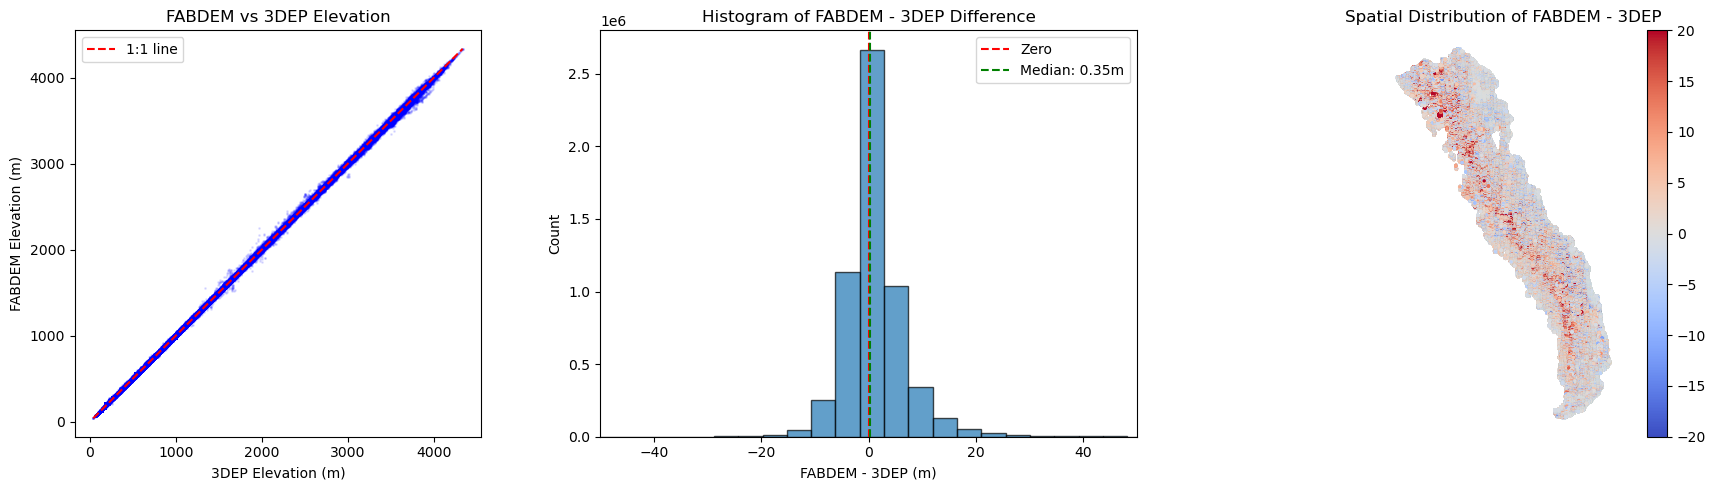

In [30]:
# Visualize FABDEM vs 3DEP comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1:1 scatter plot
ax = axes[0]
ax.scatter(atl06sr_gdf['3dep.value'], atl06sr_gdf['fabdem_elev'], 
           alpha=0.1, s=1, c='blue')
# Add 1:1 line
lims = [atl06sr_gdf['3dep.value'].min(), atl06sr_gdf['3dep.value'].max()]
ax.plot(lims, lims, 'r--', label='1:1 line')
ax.set_xlabel('3DEP Elevation (m)')
ax.set_ylabel('FABDEM Elevation (m)')
ax.set_title('FABDEM vs 3DEP Elevation')
ax.legend()
ax.set_aspect('equal')

# Histogram of differences
ax = axes[1]
diff = atl06sr_gdf['fabdem_3dep_dif'].dropna()
ax.hist(diff, bins=100, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', label='Zero')
ax.axvline(x=diff.median(), color='green', linestyle='--', label=f'Median: {diff.median():.2f}m')
ax.set_xlabel('FABDEM - 3DEP (m)')
ax.set_ylabel('Count')
ax.set_title('Histogram of FABDEM - 3DEP Difference')
ax.legend()
ax.set_xlim(-50, 50)

# Spatial map of difference
ax = axes[2]
atl06sr_gdf.plot(column='fabdem_3dep_dif', ax=ax, legend=True, 
                 cmap='coolwarm', markersize=2, vmin=-20, vmax=20)
ax.set_title('Spatial Distribution of FABDEM - 3DEP')
ax.set_axis_off()

plt.tight_layout()
plt.show()

### Access copernicus 30 m data:

In [4]:
%%time
cop30_dem = easysnowdata.topography.get_copernicus_dem(bbox_gdf)
cop30_dem

CPU times: user 35.3 ms, sys: 11.4 ms, total: 46.7 ms
Wall time: 2.2 s


<xarray.DataArray 'data' (latitude: 20263, longitude: 14711)> Size: 1GB
dask.array<getitem, shape=(20263, 14711), dtype=float32, chunksize=(20263, 14711), chunktype=numpy.ndarray>
Coordinates:
  * latitude     (latitude) float64 162kB 40.45 40.45 40.45 ... 34.82 34.82
  * longitude    (longitude) float64 118kB -121.9 -121.9 ... -117.9 -117.9
    spatial_ref  int32 4B 4326
    time         datetime64[ns] 8B 2021-04-22

### Load copernicus dem into memory for faster sampling:

In [5]:
%%time
# Option 1: Load the DEM into memory to avoid repeated Dask chunk fetches
# This is faster if the DEM fits in memory
cop30_dem_loaded = cop30_dem.load()  # This loads the entire DEM into memory
print(f"DEM loaded into memory: {cop30_dem_loaded.nbytes / 1e9:.2f} GB")

KeyboardInterrupt: 

### Save copernicus to a .nc 

## Deal with mismatching CRS (including vertical dimension):

### Set the 3dep elevation data as the z coordinate of the geometry:

In [23]:
from shapely import Point

atl06sr_gdf['geometry'] = atl06sr_gdf.apply(
    lambda row: Point(row['geometry'].x, row['geometry'].y, row['3dep.value']), 
    axis=1
)

In [29]:
atl06sr_gdf.geometry.head()

time
2018-10-14 11:40:32.488605184    POINT Z (-119.96543 39.64593 1519.33028)
2018-10-14 11:40:32.491426304    POINT Z (-119.96545 39.64575 1518.55276)
2018-10-14 11:40:32.494251264    POINT Z (-119.96548 39.64557 1518.74119)
2018-10-14 11:40:32.497075456     POINT Z (-119.9655 39.64539 1518.74347)
2018-10-14 11:40:32.499896576     POINT Z (-119.96552 39.64521 1518.8921)
Name: geometry, dtype: geometry

### Reproject the ICESat-2 data to that of the copernicus data, making sure to specify vertical CRS:

In [24]:
atl06sr_gdf_reprojected = atl06sr_gdf.to_crs("EPSG:4326+3855")

In [30]:
atl06sr_gdf_reprojected.geometry.head()

time
2018-10-14 11:40:32.488605184    POINT Z (-119.96542 39.64593 1543.31215)
2018-10-14 11:40:32.491426304    POINT Z (-119.96544 39.64575 1542.53448)
2018-10-14 11:40:32.494251264    POINT Z (-119.96546 39.64557 1542.72276)
2018-10-14 11:40:32.497075456    POINT Z (-119.96548 39.64539 1542.72489)
2018-10-14 11:40:32.499896576    POINT Z (-119.96551 39.64521 1542.87337)
Name: geometry, dtype: geometry

In [25]:
atl06sr_gdf_reprojected.crs

<Compound CRS: EPSG:9518>
Name: WGS 84 + EGM2008 height
Axis Info [ellipsoidal|vertical]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
- H[up]: Gravity-related height (metre)
Area of Use:
- undefined
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
Sub CRS:
- WGS 84
- EGM2008 height

In [52]:
cop30_dem_proj.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

### Run a test of 1000 points and difference from the transformed 3dep elevation data to ensure the CRS aligns:

In [26]:
import time

# Test sampling on a subset of 1000 points
n_test = 1000
x_test = atl06sr_gdf_reprojected.geometry.x.values[:n_test]
y_test = atl06sr_gdf_reprojected.geometry.y.values[:n_test]

x_da = xr.DataArray(x_test, dims="points")
y_da = xr.DataArray(y_test, dims="points")

start = time.time()
sampled_test = cop30_dem_loaded.sel(x=x_da, y=y_da, method="nearest")
end = time.time()

print(f"Sampled {n_test} points in {end - start:.2f} seconds.")

Sampled 1000 points in 0.02 seconds.


In [31]:
# Calculate the difference between the first 1000 '3dep.value' and sampled_test values
first_1000_3dep = atl06sr_gdf_reprojected.geometry.z.values[:1000]
diff = first_1000_3dep - sampled_test.values
print("Difference array:", diff)
diff

Difference array: [ 9.32264309e-01  5.20323240e-01  6.72714030e-01  5.05036892e-01
  6.53522337e-01  4.25787527e-01  1.67901917e-01  6.09968040e-01
  5.37019972e-01  9.61875016e-01  5.62999935e-01  1.73524584e-01
  5.14029999e-01  7.10614748e-01  4.44553198e-01  8.38526115e-01
  6.99418326e-01  4.67537471e-01  9.65759556e-01  3.68767207e-01
  1.69724543e-01  4.12576910e-01  1.85889187e-02 -7.70051961e-01
  3.26561470e-01 -2.72747566e-01  2.01966741e+00  1.29108664e+00
  1.63336274e-01  2.58124055e+00  1.43371549e+00  3.48202498e-01
  1.40123965e+00  5.67436333e-01 -4.19442784e-01  7.51027107e-01
 -4.40929385e-01 -5.98705821e-01  1.58824468e+00  9.20703357e-01
  1.95179015e-01  9.37306415e-01  6.45010357e-01  1.24114241e+00
  4.47626390e-01 -9.77847255e-01  2.50366023e-01  2.57876591e-01
 -2.42302882e-01  1.00886079e+00 -2.74032761e-01  1.79768402e-01
  1.49868226e+00  3.45062331e-01 -3.56042568e-01  1.28599256e+00
  4.57080804e-01 -9.71564881e-01  5.09944440e-01 -6.26100024e-01
  9.487

array([ 9.32264309e-01,  5.20323240e-01,  6.72714030e-01,  5.05036892e-01,
        6.53522337e-01,  4.25787527e-01,  1.67901917e-01,  6.09968040e-01,
        5.37019972e-01,  9.61875016e-01,  5.62999935e-01,  1.73524584e-01,
        5.14029999e-01,  7.10614748e-01,  4.44553198e-01,  8.38526115e-01,
        6.99418326e-01,  4.67537471e-01,  9.65759556e-01,  3.68767207e-01,
        1.69724543e-01,  4.12576910e-01,  1.85889187e-02, -7.70051961e-01,
        3.26561470e-01, -2.72747566e-01,  2.01966741e+00,  1.29108664e+00,
        1.63336274e-01,  2.58124055e+00,  1.43371549e+00,  3.48202498e-01,
        1.40123965e+00,  5.67436333e-01, -4.19442784e-01,  7.51027107e-01,
       -4.40929385e-01, -5.98705821e-01,  1.58824468e+00,  9.20703357e-01,
        1.95179015e-01,  9.37306415e-01,  6.45010357e-01,  1.24114241e+00,
        4.47626390e-01, -9.77847255e-01,  2.50366023e-01,  2.57876591e-01,
       -2.42302882e-01,  1.00886079e+00, -2.74032761e-01,  1.79768402e-01,
        1.49868226e+00,  

### Run the sampling for all ICESat-2 points:

In [32]:
import numpy as np
import xarray as xr

# Create DataArrays for x and y
x_da = xr.DataArray(atl06sr_gdf_reprojected.geometry.x.values, dims="points")
y_da = xr.DataArray(atl06sr_gdf_reprojected.geometry.y.values, dims="points")

# Use .sel with vectorized indexing
sampled = cop30_dem_loaded.sel(x=x_da, y=y_da, method="nearest")

# Assign to GeoDataFrame
atl06sr_gdf_reprojected["cop30_elev_untransformed"] = sampled.values

In [33]:
(atl06sr_gdf_reprojected["cop30_elev_untransformed"] - atl06sr_gdf_reprojected.geometry.z.values).describe()

count    5.720324e+06
mean     3.892164e+00
std      7.535189e+00
min     -1.619181e+02
25%     -5.742355e-01
50%      2.125771e+00
75%      6.965650e+00
max      3.744580e+02
Name: cop30_elev_untransformed, dtype: float64

### Replace the ICESat-2 z coordinate with the copernicus data (it used to be 3dep - only z gets transformed when I reproject)

In [34]:
# Replace geometry.z with cop30_elev_untransformed
from shapely import Point

atl06sr_gdf_reprojected['geometry'] = atl06sr_gdf_reprojected.apply(
    lambda row: Point(row.geometry.x, row.geometry.y, row['cop30_elev_untransformed']),
    axis=1
)

### Project the ICESat-2 data back into it's original CRS so that the copernicus data gets transformed:

In [36]:
atl06sr_gdf_reprojected_back = atl06sr_gdf_reprojected.to_crs(atl06sr_gdf.crs)

In [71]:
atl06sr_gdf_reprojected_back.crs

<Geographic 3D CRS: EPSG:7912>
Name: ITRF2014
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
- h[up]: Ellipsoidal height (metre)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: International Terrestrial Reference Frame 2014
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [37]:
# Create cop30_elev column from geometry.z
atl06sr_gdf_reprojected_back['cop30_elev'] = atl06sr_gdf_reprojected_back.geometry.z.values

### Now add just the copernicus data back into the original dataframe:

In [39]:
atl06sr_gdf['cop30_elev'] = atl06sr_gdf_reprojected_back['cop30_elev']

### Calculate the snow depth relative to copernicus:

In [41]:
atl06sr_gdf['icesat2_cop_dif'] = atl06sr_gdf['h_mean'] - atl06sr_gdf['cop30_elev']

In [42]:
atl06sr_gdf

,pflags,x_atc,h_mean,gt,dh_fit_dx,n_fit_photons,spot,region,cycle,h_sigma,...,decyear,dowy,acqdate,acqdate_dt,reanalysis_swe,reanalysis_sca,reanalysis_sd,icesat2_3dep_dif,cop30_elev,icesat2_cop_dif
time,,,,,,,,,,,,,,,,,,,,,
2018-10-14 11:40:32.488605184,0,15659863.0,1518.346291,50,0.011479,20,2,region_4_north,1,0.075959,...,2018.784894,14,2018-10-14,2018-10-14,0.0,0.0,0.0,-0.983984,1518.398011,-0.051720
2018-10-14 11:40:32.491426304,0,15659883.0,1518.495766,50,0.002426,26,2,region_4_north,1,0.061681,...,2018.784894,14,2018-10-14,2018-10-14,0.0,0.0,0.0,-0.056996,1518.032439,0.463327
2018-10-14 11:40:32.494251264,0,15659903.0,1518.744404,50,0.019836,32,2,region_4_north,1,0.037445,...,2018.784894,14,2018-10-14,2018-10-14,0.0,0.0,0.0,0.003210,1518.068479,0.675924
2018-10-14 11:40:32.497075456,0,15659923.0,1518.924909,50,-0.002168,34,2,region_4_north,1,0.033904,...,2018.784894,14,2018-10-14,2018-10-14,0.0,0.0,0.0,0.181442,1518.238430,0.686478
2018-10-14 11:40:32.499896576,0,15659943.0,1518.817927,50,-0.006208,36,2,region_4_north,1,0.047438,...,2018.784894,14,2018-10-14,2018-10-14,0.0,0.0,0.0,-0.074177,1518.238581,0.579345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-30 07:56:02.104347136,0,16052711.0,226.890584,40,-0.054218,20,3,region_1_south,13,0.076027,...,2021.746111,365,2021-09-30,2021-09-30,0.0,0.0,0.0,0.773256,225.544263,1.346321
2021-09-30 07:56:02.107133952,0,16052731.0,225.671663,40,-0.069895,20,3,region_1_south,13,0.065225,...,2021.746111,365,2021-09-30,2021-09-30,0.0,0.0,0.0,0.516851,225.543269,0.128394
2021-09-30 07:56:02.109926144,0,16052751.0,224.486863,40,-0.044743,16,3,region_1_south,13,0.051071,...,2021.746111,365,2021-09-30,2021-09-30,0.0,0.0,0.0,-0.167102,224.151513,0.335350


In [31]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2019, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [32]:
swe_sca_ds.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [33]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [34]:
swe_sca_ds = swe_sca_ds.rename({'y': 'lat', 'x': 'lon'})
swe_sca_ds_allyrs = swe_sca_ds_allyrs.rename({'y': 'lat', 'x': 'lon'})

In [35]:
# 1. Select April 1 of each year
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs.sel(time=( (swe_sca_ds_allyrs['time'].dt.month == 4) & (swe_sca_ds_allyrs['time'].dt.day == 1) ))

In [36]:
# 2. Compute mean April 1 snow depth across years
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_april1.mean(dim='time', skipna=True)

In [37]:
# 3. Threshold mask
mask = swe_sca_ds_allyrs_april1.SCA_Post > 0.5

In [38]:
# 4. Apply mask
swe_sca_ds_roi = swe_sca_ds.where(mask)

In [39]:
# 5. Compute spatial median
median_sd = swe_sca_ds_roi.median(dim=('lat', 'lon'), skipna=True).compute()

### Sample mask at ICESat-2 points:

In [40]:
latitudes = xr.DataArray(atl06sr_gdf.to_crs('epsg:4326').geometry.y.values, dims="points")
longitudes = xr.DataArray(atl06sr_gdf.to_crs('epsg:4326').geometry.x.values, dims="points")

In [41]:
mask_da = mask.astype(np.int32)

In [42]:
#atl06sr_gdf['mask'] = np.nan

sampled_mask = mask_da.sel(lat=latitudes, lon=longitudes, method='nearest').values

In [43]:
atl06sr_gdf['mask'] = sampled_mask

### Subsest the ICESat-2 data by snow cover and slope to calculate sample size:

In [44]:
atl06sr_gdf_snowy = atl06sr_gdf[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['3dep.slope']<20)]

In [45]:
atl06sr_gdf_snowy['n'] = atl06sr_gdf_snowy.groupby('acqdate')['acqdate'].transform('count')

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [44]:
# atl06sr_gdf_snowy['acqdate_dt'] = pd.to_datetime(atl06sr_gdf_snowy['acqdate'])

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


### plot reanalysis as boxplots on ICESat-2 acquisition dates at sampled locations:

In [46]:
highlight_dates = ['2019-03-16','2020-04-11','2021-04-01']

In [47]:
import matplotlib.dates as mdates
import matplotlib.cbook as cbook
from matplotlib.ticker import FuncFormatter

In [48]:
import datetime
from matplotlib.lines import Line2D
#from datetime import datetime

In [49]:
mpl_epoch = '1970-01-01'

In [50]:
highlight_dates_dt = pd.to_datetime(highlight_dates)

In [51]:
icesat2_color = '#69BC6B'
icesat2_median_color = '#64A366' # '#6BB567' 
reanalysis_color = '#1C6BAB'
highlight_color2 = '#750075' # purple
#highlight_color = '#FF9D98' # coral
#highlight_color = '#FD8D3C' # orange
highlight_color = '#E6550D' # reddish orange

In [52]:
# Function adapted from David Shean by Hannah Besso
# Allows for multiple levels of data to be plotted. Can just plot in situ snow depth, or can add any/all of the following:
# ICESat-2, sampled ASO, and full-site ASO

def boxplot_timeseries_highlights(df=None, col=None, groupby_col='acqdate', highlights=None,
                         title='Sierras Median Snow Depth', name='../figures/boxplots_cdec_aso.jpeg', 
                         main_color=None, highlight_color=None, clim=(-2, 5)):
    
    df_nh = df[~df['acqdate_dt'].isin(highlights)]
    df_h = df[df['acqdate_dt'].isin(highlights)]

    # ATL06 stats
    if df is not None:
        bp_stats_nh = df_nh[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        bp_stats_list_nh = [i[0] for i in bp_stats_nh.values]
        bp_alpha_nh = df_nh[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        bp_alpha_boxes_nh = bp_alpha_nh/bp_alpha_nh.max()
        pos_nh = (pd.to_datetime(bp_stats_nh.index) - pd.to_datetime(mpl_epoch)).days.values

    if highlights is not None:
        bp_stats_h = df_h[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        bp_stats_list_h = [i[0] for i in bp_stats_h.values]
        bp_alpha_h = df_h[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        bp_alpha_boxes_h = bp_alpha_h/bp_alpha_h.max()
        pos_h = (pd.to_datetime(bp_stats_h.index) - pd.to_datetime(mpl_epoch)).days.values
    
    f, ax = plt.subplots(figsize=(15,7))
    
    median_sd.SD_Post.plot(label='Spatial Median (Apr 1 Mean fSCA > 0.5 mm)', color='k', linewidth=1)
    
    # Plot ATL06 data
    if df is not None:
        bxp_f_nh = ax.bxp(bp_stats_list_nh, positions=pos_nh, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.3, 'facecolor':main_color},  
                   medianprops={'lw':3, 'color':main_color},widths=10, patch_artist=True, zorder=1)
        for patch, alpha in zip(bxp_f_nh['boxes'], bp_alpha_boxes_nh):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

       # Plot highlight data
    if highlights is not None:
        bxp_f_h = ax.bxp(bp_stats_list_h, positions=pos_h, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.5, 'facecolor':highlight_color},  
                   medianprops={'lw':3, 'color':highlight_color},widths=10, patch_artist=True, zorder=2)
        for patch, alpha in zip(bxp_f_h['boxes'], bp_alpha_boxes_h):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

    ax.set_title(title, fontsize=24)
    
    
    #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
    # if df is not None:
    #     for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    #         patch.set_edgecolor('None')
    #         patch.set_linewidth(0)
    # if df is not None:
    #     for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    #         patch.set_color('k')  # or deeppink  
    
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('Snow Depth (m)', fontsize=22)
    ax.set_ylim(*clim)
    ax.set_xlim([dt_min_plot, dt_max_plot])
    
    
    # X AXIS LABELS     
    months = mdates.MonthLocator()
    month_fmt = mdates.DateFormatter('%b')
    
    def m_fmt(x, pos=None):
        return month_fmt(x)[0]
    
    ax.xaxis.set_minor_locator(months) 
    ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))
    
    years = mdates.MonthLocator(bymonth=1)
    ax.format_xdata = mdates.DateFormatter('%Y')
    years_fmt = mdates.DateFormatter('%Y')
    ax.xaxis.set_major_locator(years)
    ax.xaxis.set_major_formatter(years_fmt)
    ax.tick_params('both', length=5, width=1.5, which='major')
    ax.tick_params('both', length=5, width=1.5, which='minor')
    
    #ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10
    
    for label in ax.get_xticklabels(which='major'): #
        label.set(rotation=90, horizontalalignment='center')
    
    plt.tight_layout()
    #plt.savefig(f'{name}', dpi=500)

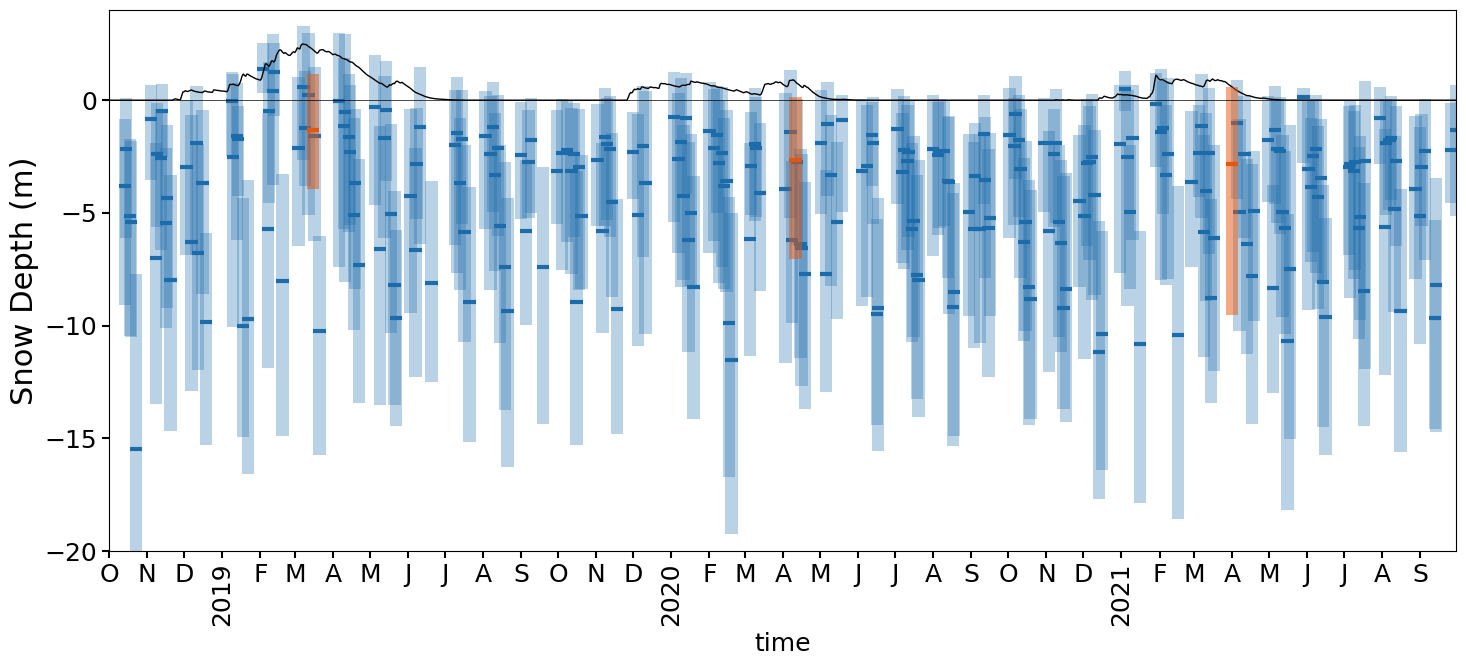

In [70]:
plt.rcParams['font.size'] = '18'
dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)

boxplot_timeseries_highlights(df=atl06sr_gdf_snowy[atl06sr_gdf_snowy['n']>100], col='icesat2_cop_dif', groupby_col='acqdate', highlights=highlight_dates_dt,
                         title='', name='../../figures/boxplots_reanalysis_highlights.png', 
                         main_color=reanalysis_color, highlight_color=highlight_color, clim=(-20, 4))

In [55]:
atl06sr_gdf_snowy['icesat2_fabdem_dif'] = atl06sr_gdf_snowy['h_mean'] - atl06sr_gdf_snowy['fabdem_elev']

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


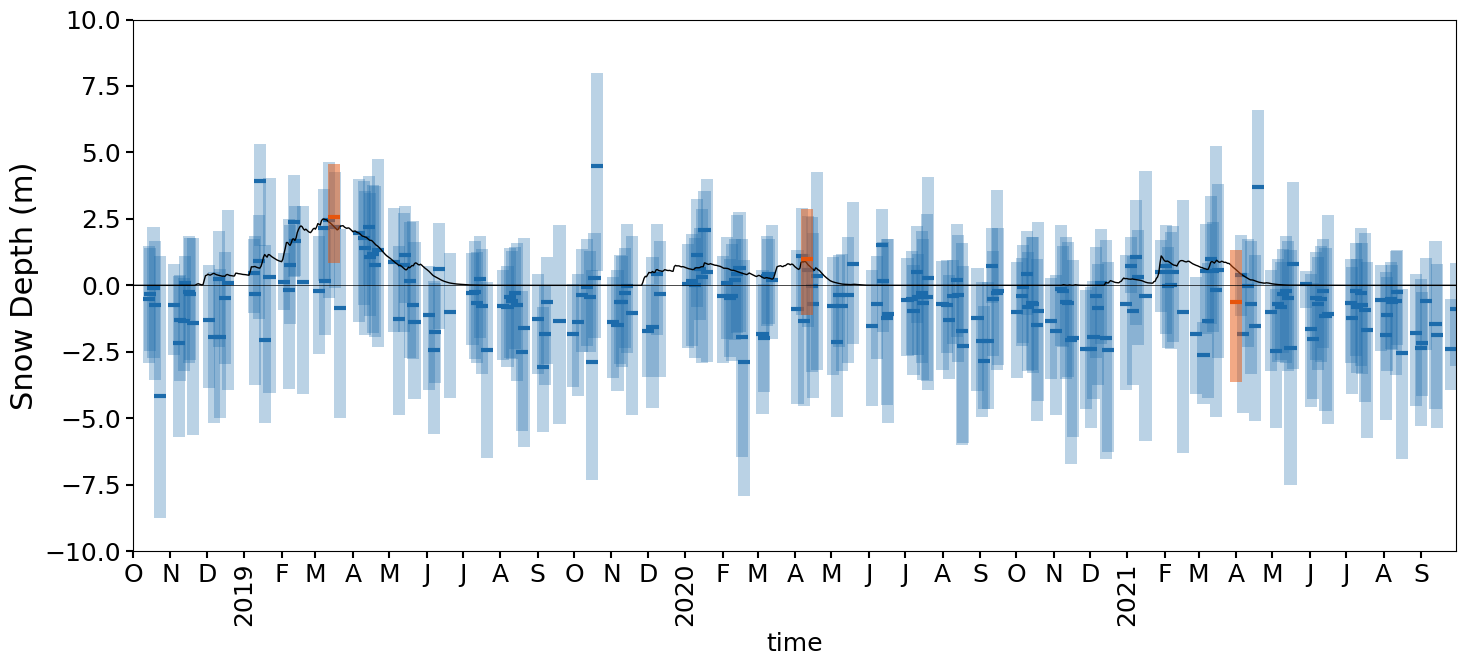

In [59]:
plt.rcParams['font.size'] = '18'
dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)

boxplot_timeseries_highlights(df=atl06sr_gdf_snowy[atl06sr_gdf_snowy['n']>100], col='icesat2_fabdem_dif', groupby_col='acqdate', highlights=highlight_dates_dt,
                         title='', name='../../figures/boxplots_reanalysis_highlights.png', 
                         main_color=reanalysis_color, highlight_color=highlight_color, clim=(-10, 10))